### Practice Assignment

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

In [2]:
import requests
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv"
response = requests.get(url)

with open("PracticeDataset.csv", "wb") as f:
    f.write(response.content)

### Task 1 : Import the dataset
Import the dataset into a pandas dataframe. Note that there are currently no headers in the CSV file.

Print the first 10 rows of the dataframe to confirm successful loading.

In [4]:
df = pd.read_csv("PracticeDataset.csv", header=None)
df.head(10)

,19,1,27.9,0,1.1,3,16884.924
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160
5,46,1,33.440,1,0,4,8240.58960
6,37,1,27.740,3,0,1,7281.50560
7,37,2,29.830,2,0,2,6406.41070
8,60,1,25.840,0,0,1,28923.13692
9,25,2,26.220,0,0,2,2721.32080


Add the headers to the dataframe, as mentioned in the project scenario.

In [5]:
headers=["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns=headers
df.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160
5,46,1,33.440,1,0,4,8240.58960
6,37,1,27.740,3,0,1,7281.50560
7,37,2,29.830,2,0,2,6406.41070
8,60,1,25.840,0,0,1,28923.13692
9,25,2,26.220,0,0,2,2721.32080


Now, replace the '?' entries with 'NaN' values.

In [6]:
df.replace("?", np.nan, inplace=True)
df.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,NaN,4,3756.62160
5,46,1,33.440,1,0,4,8240.58960
6,37,1,27.740,3,0,1,7281.50560
7,37,2,29.830,2,0,2,6406.41070
8,60,1,25.840,0,0,1,28923.13692
9,25,2,26.220,0,0,2,2721.32080


### Task 2 : Data Wrangling
Use dataframe.info() to identify the columns that have some 'Null' (or NaN) information.

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2767 non-null   object 
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_children  2771 non-null   int64  
 4   smoker          2764 non-null   object 
 5   region          2771 non-null   int64  
 6   charges         2771 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB
None


Handle missing data:

For continuous attributes (e.g., age), replace missing values with the mean.
For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
Update the data types of the respective columns.
Verify the update using df.info().

In [ ]:
# smoker is a categorical attribute, replace with most frequent entry
is_smoker = df["smoker"].value_counts().idxmax()
df["smoker"].replace(np.nan, is_smoker, inplace=True)

# age is a continuous variable, replace with mean age
mean_age = df["age"].astype("float").mean(axis=0)
df["age"].replace(np.nan, mean_age, inplace=True)

# Update Data Types
df[["age", "smoker"]] = df[["age", "smoker"]].astype("int")

print(df.info())

Also note, that the charges column has values which are more than 2 decimal places long. Update the charges column such that all values are rounded to nearest 2 decimal places. Verify conversion by printing the first 5 values of the updated dataframe.

In [8]:
df[["charges"]] = np.round(df[["charges"]], 2)
print(df.head())

  age  gender     bmi  no_of_children smoker  region   charges
0  18       2  33.770               1      0       4   1725.55
1  28       2  33.000               3      0       4   4449.46
2  33       2  22.705               0      0       1  21984.47
3  32       2  28.880               0      0       1   3866.86
4  31       1  25.740               0    NaN       4   3756.62


### Task 3 : Exploratory Data Analysis (EDA)
Implement the regression plot for charges with respect to bmi.

(0.0, 66902.85800000001)

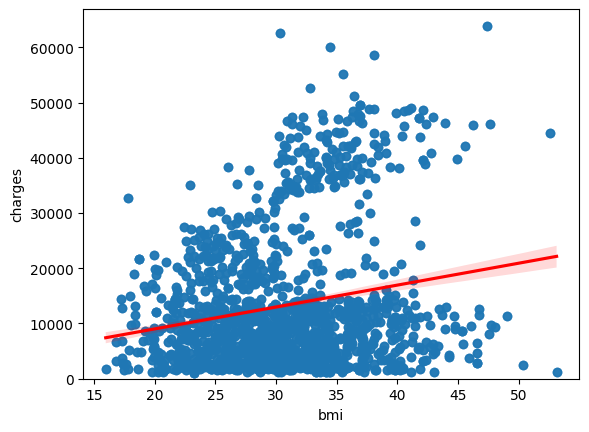

In [13]:
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)

Implement the box plot for charges with respect to smoker.

<Axes: xlabel='smoker', ylabel='charges'>

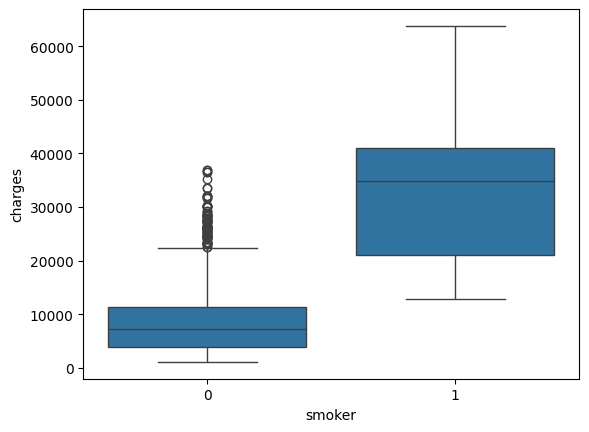

In [14]:
sns.boxplot(x="smoker", y="charges", data=df)

Print the correlation matrix for the dataset.

In [16]:
print(df.corr())

                  gender       bmi  no_of_children    region   charges
gender          1.000000  0.042766        0.015693  0.022360  0.062959
bmi             0.042766  1.000000       -0.001642  0.271200  0.199906
no_of_children  0.015693 -0.001642        1.000000 -0.025594  0.066551
region          0.022360  0.271200       -0.025594  1.000000  0.054018
charges         0.062959  0.199906        0.066551  0.054018  1.000000


/var/folders/7l/2xnthlg51zb55w1vmgw9x2br0000gn/T/ipykernel_23759/4212406737.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(df.corr())
